# Lead-time forecast skill, 1-7 days

The companion notebook (`02_models_vs_swalim.ipynb`) scores **reanalysis** :
how well each model reproduces the river given observed rainfall. That is a
skill ceiling, not trigger skill. This notebook scores the **forecasts**: what
an operational trigger would actually have seen 1-7 days ahead.

| source | product | period | members |
|---|---|---|---|
| `glofas` | GloFAS v4 reforecast, leads 1-7 d | 2003-2023, Gu + Deyr | 11 (control + 10 perturbed) |
| `google` | Google GRRR reforecast, leads 0-7 d | 2016-2023 | 1 (deterministic) |
| `geoglows` | archived daily inits, leads 0-14 d | 2024-07 to 2026-08 | 52 |

The three archives **do not overlap in time** (GloFAS/GRRR end 2023, GEOGloWS
starts mid-2024), so each source's lead-time skill is measurable but a
head-to-head on identical events is not possible.

Constraint carried over: triggers must target **RP3 or rarer**.

**GloFAS here is v4 by necessity**: EWDS publishes no v5 reforecast (form
checked 2026-08-06: versions offered stop at 4.0), so v5's superior
reanalysis (notebook 02) cannot yet be exercised at lead time. The observed
benchmark is the **official Moderate Flood Risk level** throughout: the
operational SWALIM benchmark (standardized 2026-08-06).

### Threshold transfer: check before trusting any RP threshold on a forecast

A forecast and its own reanalysis need not share a climatology. Verified per
source (section 1):

* **GloFAS: they match** (median ratio 1.00 at lead 1, 0.89-0.95 at lead 7),
  because reanalysis and reforecast are both LISFLOOD v4.0 on ECMWF forcing.
  Reanalysis-fitted RPs therefore transfer.
* **GEOGloWS: they do NOT** (forecast median 0.60x its retrospective at Belet
  Weyne, 0.70x at Luuq; the forecast maximum never reaches RP3). Its
  retrospective is ERA5-driven while forecasts are IFS-driven. Applying
  retrospective RPs to its forecasts produces spurious zeros.

GloFAS RPs are Gumbel fits to its own reanalysis annual maxima (EWDS publishes
none per cell): in-sample against the evaluation window, so its FAR is mildly
flattered.

In [1]:
import sys

sys.path.insert(0, "..")

import os
import tempfile
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import ocha_stratus as stratus
import geopandas as gpd, tempfile, os

from src.constants import (
    SEASONS,
    SEASON_MONTHS,
    EXP_SEASONS,
    STATIONS,
    INK,
    BODY,
    FAINT,
    GRID,
    C_MOD,
    C_HIGH,
    C_GU,
    C_DEYR,
    C_JUBA,
    C_SHAB,
    C_MAIN,
    C_ISOL,
    C_JOINT,
    C_BAND,
    C_BAND_EDGE,
    C_REF,
    C_GEOGLOWS,
    C_GOOGLE,
    C_GLOFAS4,
    C_GLOFAS5,
    C_SWALIM,
    C_SFED,
    SOURCE_COLORS,
)
from src.plots import apply_chart_style, style_ax
from src.utils import (
    auc,
    episodes,
    gumbel_rp,
    hits,
    weibull_level,
    weibull_threshold,
    yT,
)

apply_chart_style()


In [2]:
def load(name):
    return stratus.load_parquet_from_blob(
        f"ds-aa-som-floods/processed/{name}.parquet", stage="dev")

rf_glofas = load("reforecast_glofas_v4")
rf_grrr = load("reforecast_google_grrr")
rf_geo = load("reforecast_geoglows")
ra_glofas = load("discharge_daily_glofas_v4")
ra_geo = load("discharge_daily_geoglows")
lv = load("swalim_levels").set_index(["station", "date"])["level_m"]
th = load("swalim_thresholds").set_index("station")

gauged = [s for s in th.index if s in lv.index.get_level_values(0)]
print("GloFAS reforecast:", rf_glofas.issued_time.nunique(), "issue dates,",
      rf_glofas.member.nunique(), "members,",
      f"{rf_glofas.issued_time.min().date()} -> {rf_glofas.issued_time.max().date()}")


GloFAS reforecast: 2080 issue dates, 11 members, 2003-03-27 -> 2023-11-25


## Station map

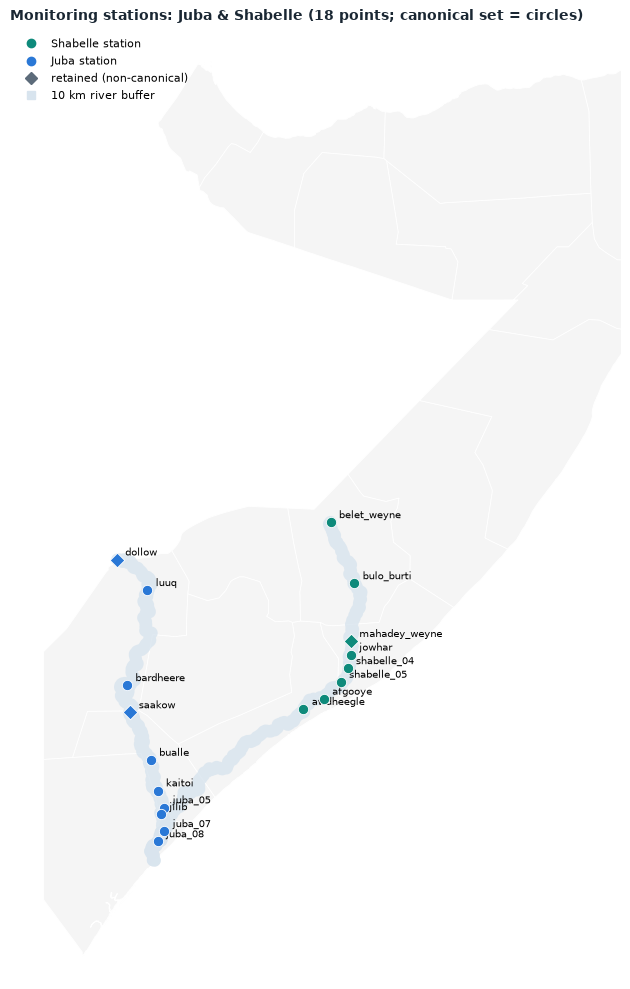

In [3]:
# admin boundaries + river buffers for context
adm1 = stratus.codab.load_codab_from_blob("som", admin_level=1)
_raw = stratus.load_blob_data("ds-aa-som-floods/processed/workflow/som_river_buffers.gpkg", stage="dev")
_tmp = os.path.join(tempfile.gettempdir(), "som_river_buffers.gpkg")
open(_tmp, "wb").write(_raw)
bufs = gpd.read_file(_tmp)

fig, ax = plt.subplots(figsize=(9, 10))
adm1.plot(ax=ax, color="#F5F5F5", edgecolor="white", linewidth=0.6)
bufs.plot(ax=ax, color="#D8E4EE", alpha=0.8)
RIVER_COLORS = {"shabelle": C_SHAB, "juba": C_JUBA}
for key, st in STATIONS.items():
    c = RIVER_COLORS[st.river]
    marker = "o" if st.canonical else "D"
    ax.scatter(st.lon, st.lat, color=c, marker=marker, s=55, zorder=5,
               edgecolors="white", linewidths=0.6)
    ax.annotate(key, (st.lon, st.lat), textcoords="offset points",
                xytext=(6, 3), fontsize=7)
handles = [
    plt.Line2D([], [], color=C_SHAB, marker="o", ls="", label="Shabelle station"),
    plt.Line2D([], [], color=C_JUBA, marker="o", ls="", label="Juba station"),
    plt.Line2D([], [], color=C_REF, marker="D", ls="", label="retained (non-canonical)"),
    plt.Line2D([], [], color="#D8E4EE", marker="s", ls="", label="10 km river buffer"),
]
ax.legend(handles=handles, loc="upper left", fontsize=8)
ax.set_xlim(40.5, 49.5); ax.set_ylim(-2, 12)
ax.set_title("Monitoring stations: Juba & Shabelle (18 points; canonical set = circles)", loc="left", fontsize=10)
ax.set_axis_off()
plt.tight_layout()


## 1. Does the forecast share its reanalysis climatology?

Median discharge on the same days, forecast vs reanalysis. A ratio near 1
means reanalysis-fitted return periods can be applied to the forecast.

In [4]:
rows = []
for st in gauged:
    ra = ra_glofas[ra_glofas.station == st].set_index("date")["discharge"]
    for lead in (1, 4, 7):
        f = rf_glofas[(rf_glofas.station == st) & (rf_glofas.leadtime_days == lead)]
        med = f.groupby("valid_time")["discharge"].median()
        j = pd.concat([med.rename("fc"), ra.rename("ra")], axis=1, join="inner").dropna()
        if len(j) < 200:
            continue
        rows.append({"station": st, "source": "glofas", "lead": lead,
                     "ratio": j.fc.median() / j.ra.median(), "n_days": len(j)})
# GEOGloWS, for contrast
for st in gauged:
    ra = ra_geo[ra_geo.station == st].set_index("date")["discharge"]
    for lead in (1, 4, 7):
        f = rf_geo[(rf_geo.station == st) & (rf_geo.leadtime_days == lead)]
        if not len(f):
            continue
        med = f.groupby("valid_time")["discharge"].median()
        j = pd.concat([med.rename("fc"), ra.rename("ra")], axis=1, join="inner").dropna()
        if len(j) < 200:
            continue
        rows.append({"station": st, "source": "geoglows", "lead": lead,
                     "ratio": j.fc.median() / j.ra.median(), "n_days": len(j)})
clim = pd.DataFrame(rows)
clim.pivot(index="station", columns=["source", "lead"], values="ratio").round(2)


source        glofas             geoglows            
lead               1     4     7        1     4     7
station                                              
afgooye          1.0  0.99  0.96     0.62  0.60  0.60
awdheegle        1.0  1.00  0.96     0.62  0.60  0.57
bardheere        1.0  0.98  0.92     0.71  0.70  0.67
belet_weyne      1.0  0.98  0.94     0.60  0.60  0.59
bualle           1.0  0.99  0.94     0.70  0.70  0.70
bulo_burti       1.0  0.99  0.95     0.60  0.60  0.61
dollow           1.0  0.96  0.89     0.69  0.65  0.59
jowhar           1.0  1.00  0.96     0.59  0.58  0.60
kaitoi           1.0  1.00  0.95     0.70  0.70  0.71
luuq             1.0  0.97  0.90     0.70  0.66  0.62
mahadey_weyne    1.0  0.99  0.96     0.59  0.58  0.60

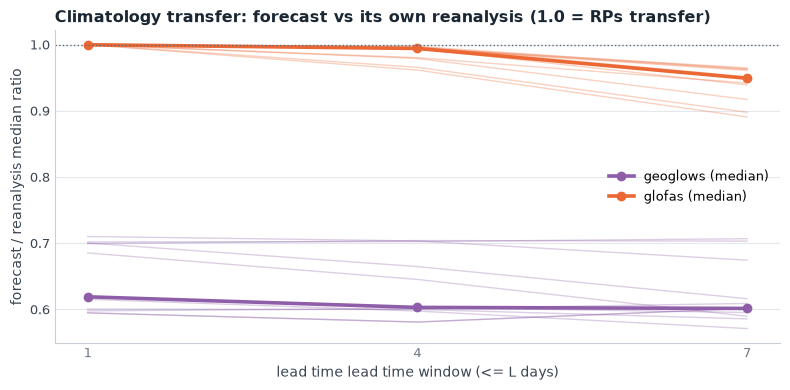

In [5]:
SRC_C = {"glofas": C_GLOFAS4, "geoglows": C_GEOGLOWS}
fig, ax = plt.subplots(figsize=(8, 4))
for srcname, g in clim.groupby("source"):
    for stn, gs in g.groupby("station"):
        gs = gs.sort_values("lead")
        ax.plot(gs.lead, gs.ratio, color=SRC_C[srcname], alpha=0.3, lw=1)
    med = g.groupby("lead")["ratio"].median()
    ax.plot(med.index, med.values, color=SRC_C[srcname], lw=2.6, marker="o",
            label=f"{srcname} (median)")
ax.axhline(1.0, color=C_REF, ls=":", lw=1)
ax.set_xticks([1, 4, 7])
ax.set_xlabel("lead time lead time window (<= L days)")
ax.set_ylabel("forecast / reanalysis median ratio")
ax.set_title("Climatology transfer: forecast vs its own reanalysis (1.0 = RPs transfer)")
ax.legend()
style_ax(ax, grid="y")
plt.tight_layout()


## 2. Performance against actual flood events

The question that matters: **for each real flood, would the forecast have
seen it coming, and from how far out?**

- An *event* is an episode where the observed level stood at or above a
  benchmark (14-day recession rule). **Both benchmarks are scored**: the
  official Moderate Flood Risk level and the post-2000 RP3 (one POD/FAR
  figure per benchmark; the per-event strip and station heatmaps show the
  Moderate slice).
- The curves read as **"detected at least L days ahead"**: the point at
  L = 7 counts only events flagged a full week out, the point at L = 1
  counts events flagged at all. POD is therefore monotonically
  non-increasing in L, as it should be: demanding more lead time can only
  lose events. Alarms are constructed once (union of all leads), tagged
  with the longest lead at which they fired, and filtered by "fired at
  >= L days". The cost panel plots **false alarms per station-year**, a
  count that is monotone in L by construction; the FAR ratio
  (false/surviving alarms) is kept in the tables and station heatmaps,
  where its non-monotonicity is informative rather than confusing (a dip
  means the surviving long-lead alarms are the more reliable ones).
- Plots are disaggregated **by season (Gu | Deyr)**, one figure per
  benchmark and season.
- Sources: GloFAS v4 at **>= 50% member probability** (at least half the
  11-member ensemble over the station's RP3) and Google GRRR (single
  deterministic run, its own 50% point).
- Two windows are shown side by side: each source's **full archive**
  (GloFAS 2003-2023, dashed) and the **common 2016-2023 window** (solid),
  where both sources face the exact same events and are directly
  comparable. GEOGloWS is
  excluded here: its archive (2024-) is too short to contain enough events.

Three views: share of events detected by lead | false alarms per year by
lead | every event with the lead time it actually got.

- Dotted horizontal lines on the POD panels are each source's
  **reanalysis ceiling**: the share of the same events its reanalysis
  (perfect rainfall foresight) crosses the same threshold for. The gap
  between a source's ceiling and its forecast curve is the cost of
  forecasting; the gap between the ceiling and 100% is the model's
  hydrology failing that river.


In [ ]:
# observed event benchmarks: official Moderate AND post-2000 RP3
MODERATE = {st: th.loc[st, "moderate_flood_risk"] for st in gauged}
EV_POST2000 = {}
for st in gauged:
    s = lv.loc[st]
    s2 = s[s.index.year >= 2000]
    am = s2.groupby(s2.index.year).max().dropna()
    EV_POST2000[st] = weibull_level(am.values, 3)
OBS_BENCH = {"moderate": MODERATE, "rp3_post2000": EV_POST2000}

grrr_rp = load("return_periods_google_grrr").pivot(
    index="station", columns="return_period", values="discharge"
)

def grrr_q3(st):
    if st not in grrr_rp.index:
        return np.nan
    q2, q5 = grrr_rp.loc[st, 2], grrr_rp.loc[st, 5]
    return q2 + (q5 - q2) * (yT(3) - yT(2)) / (yT(5) - yT(2))

# GloFAS: probability formulation. Per (station, valid_time, lead), the share
# of ensemble members at or above the station's RP3; trigger at >= 50%.
GF_Q3 = {
    st: gumbel_rp(
        ra_glofas[ra_glofas.station == st].set_index("date")["discharge"], 3
    )
    for st in gauged
}
gf_prob = (
    rf_glofas.assign(hit=lambda d: d.discharge >= d.station.map(GF_Q3))
    .groupby(["station", "valid_time", "leadtime_days"])["hit"]
    .mean()
    .rename("val")
    .reset_index()
)
gr_det = rf_grrr[rf_grrr.leadtime_days >= 1].rename(columns={"discharge": "val"})

GF_THRESH = {st: 0.5 for st in gauged}  # >=50% of members over RP3
GR_THRESH = {st: grrr_q3(st) for st in gauged}  # deterministic single run
# two evaluation windows: each source's full archive, and the common window
SRC_FC = {
    ("glofas", "full"): {"frame": gf_prob, "thresh": GF_THRESH, "window": (2003, 2023)},
    ("glofas", "common"): {"frame": gf_prob, "thresh": GF_THRESH, "window": (2016, 2023)},
    ("google", "full"): {"frame": gr_det, "thresh": GR_THRESH, "window": (2016, 2023)},
    ("google", "common"): {"frame": gr_det, "thresh": GR_THRESH, "window": (2016, 2023)},
}

# reanalysis series per source: the skill ceiling (perfect rainfall foresight)
dd_gr = load("discharge_daily_google_grrr")
dd_gr["date"] = pd.to_datetime(dd_gr["date"])
REANA = {
    "glofas": {st: ra_glofas[ra_glofas.station == st].set_index("date")["discharge"]
               for st in gauged},
    "google": {st: dd_gr[dd_gr.station == st].set_index("date")["discharge"]
               for st in gauged},
}
REANA_THRESH = {"glofas": GF_Q3, "google": GR_THRESH}

TOL = pd.Timedelta(days=7)
LEADS_EV = list(range(1, 8))
event_rows = []
for st in gauged:
  for bench_name, thr_map in OBS_BENCH.items():
    thr = thr_map.get(st, np.nan)
    if np.isnan(thr):
        continue
    obs = lv.loc[st]
    for s0, e0 in episodes(obs >= thr):
        season = (
            "gu" if s0.month in SEASONS["gu"]
            else ("deyr" if s0.month in SEASONS["deyr"] else "other")
        )
        for (src_name, wtype), cfg in SRC_FC.items():
            y0, y1 = cfg["window"]
            if not (y0 <= s0.year <= y1):
                continue
            t = cfg["thresh"].get(st, np.nan)
            if np.isnan(t):
                continue
            d = cfg["frame"]
            sub = d[
                (d.station == st)
                & (d.valid_time >= s0 - TOL)
                & (d.valid_time <= e0 + TOL)
            ]
            if not len(sub):
                continue  # no forecast coverage of this event window
            row = {
                "station": st,
                "river": STATIONS[st].river,
                "season": season,
                "start": s0,
                "year": int(s0.year),
                "source": src_name,
                "wtype": wtype,
                "bench": bench_name,
            }
            for L in LEADS_EV:
                dl = sub[sub.leadtime_days == L]
                row[f"det_{L}"] = bool(len(dl)) and bool((dl.val >= t).any())
            row["max_warning"] = max(
                [L for L in LEADS_EV if row[f"det_{L}"]], default=0
            )
            ra = REANA[src_name].get(st)
            t_ra = REANA_THRESH[src_name].get(st, np.nan)
            ra_win = ra.loc[s0 - TOL : e0 + TOL] if ra is not None else None
            row["det_reana"] = bool(
                ra_win is not None
                and len(ra_win)
                and not np.isnan(t_ra)
                and (ra_win >= t_ra).any()
            )
            event_rows.append(row)
events_tab = pd.DataFrame(event_rows)

# false alarms under the "at least L days ahead" policy. Each alarm episode
# is defined ONCE (union of all leads), tagged with the longest lead at
# which the signal fired, and classified hit/false ONCE against the
# observed events; the per-L rows then simply filter alarms with
# max_lead >= L, so alarm counts are monotone in L by construction.
fa_rows = []
for (src_name, wtype), cfg in SRC_FC.items():
    y0, y1 = cfg["window"]
    n_years = y1 - y0 + 1
    for st in gauged:
      for bench_name, thr_map in OBS_BENCH.items():
        thr = thr_map.get(st, np.nan)
        t = cfg["thresh"].get(st, np.nan)
        if np.isnan(thr) or np.isnan(t):
            continue
        obs = lv.loc[st]
        obs_ev_all = episodes(obs >= thr)
        d = cfg["frame"]
        dsub = d[(d.station == st)
                 & (d.valid_time.dt.year >= y0)
                 & (d.valid_time.dt.year <= y1)]
        if not len(dsub):
            continue
        # day-level hit sets per lead + the all-leads union series
        hit_days = {
            L: set(dsub[(dsub.leadtime_days == L) & (dsub.val >= t)].valid_time)
            for L in LEADS_EV
        }
        s_all = dsub.groupby("valid_time")["val"].max().sort_index()
        alarms = []  # (start, end, max_lead, is_false, season)
        for a0, a1 in episodes(s_all >= t):
            max_lead = max(
                (L for L in LEADS_EV
                 if any(a0 <= v <= a1 for v in hit_days[L])),
                default=0,
            )
            is_false = hits([(a0, a1)], obs_ev_all) == 0
            a_season = (
                "gu" if a0.month in SEASONS["gu"]
                else ("deyr" if a0.month in SEASONS["deyr"] else "other")
            )
            alarms.append((a0, a1, max_lead, is_false, a_season))
        for season_name in SEASONS:
            for L in LEADS_EV:
                sel = [a for a in alarms if a[4] == season_name and a[2] >= L]
                fa_rows.append(
                    {
                        "station": st,
                        "river": STATIONS[st].river,
                        "source": src_name,
                        "wtype": wtype,
                        "bench": bench_name,
                        "season": season_name,
                        "lead": L,
                        "n_alarms": len(sel),
                        "n_false": sum(1 for a in sel if a[3]),
                        "false_alarms_per_year": sum(1 for a in sel if a[3]) / n_years,
                    }
                )
fa_tab = pd.DataFrame(fa_rows)
print(
    events_tab.groupby(["bench", "source", "wtype", "river"]).size().rename("n_events").to_string()
)


In [7]:
# The events themselves: observed episodes of level >= the station's
# official Moderate Flood Risk level (14-day recession rule; same events
# as notebook 01's Moderate crossing counts). Value = longest lead (days)
# at which the source detected the event; 0 = missed at every lead; NaN =
# outside that source's archive window or forecast coverage.
ev_list = (
    events_tab[events_tab.wtype == "full"]
    .assign(date=lambda d: d.start.dt.date)
    .pivot_table(index=["river", "station", "date"], columns=["bench", "source"],
                 values="max_warning")
)
ev_list


bench                         moderate        rp3_post2000       
source                          glofas google       glofas google
river    station   date                                          
juba     bardheere 2005-05-23      4.0    NaN          NaN    NaN
                   2006-05-02      0.0    NaN          NaN    NaN
                   2006-10-24      0.0    NaN          NaN    NaN
                   2006-10-30      NaN    NaN          0.0    NaN
                   2008-10-16      0.0    NaN          NaN    NaN
...                                ...    ...          ...    ...
shabelle jowhar    2020-09-12      5.0    0.0          NaN    NaN
                   2021-08-13      NaN    0.0          NaN    NaN
                   2021-08-21      NaN    NaN          NaN    0.0
                   2022-05-07      0.0    0.0          NaN    NaN
                   2023-11-21      0.0    NaN          NaN    NaN

[161 rows x 4 columns]

In [ ]:
LINES = [
    ("glofas", "full", C_GLOFAS4, "--", "GloFAS v4 >=50%, full 2003-23"),
    ("glofas", "common", C_GLOFAS4, "-", "GloFAS v4 >=50%, common 2016-23"),
    ("google", "common", C_GOOGLE, "-", "Google GRRR, 2016-23"),
]
SRC_LABEL = {
    "glofas": "GloFAS v4, >=50% of members",
    "google": "Google GRRR, deterministic",
}
for bench_name, bench_label in [
    ("moderate", "official Moderate"),
    ("rp3_post2000", "post-2000 RP3"),
]:
  for season in ["gu", "deyr"]:
    fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True)
    for j, river in enumerate(["juba", "shabelle"]):
        ax = axes[0][j]
        for src_name, wtype, color, ls, lab in LINES:
            sub = events_tab[
                (events_tab.bench == bench_name)
                & (events_tab.river == river)
                & (events_tab.season == season)
                & (events_tab.source == src_name)
                & (events_tab.wtype == wtype)
            ]
            if not len(sub):
                continue
            rate = [100 * (sub.max_warning >= L).mean() for L in LEADS_EV]
            ax.plot(LEADS_EV, rate, marker="o", lw=2, color=color, ls=ls,
                    label=f"{lab} | {len(sub)} events")
        # dotted horizontals = reanalysis ceiling per source
        for src_name, color in [("glofas", C_GLOFAS4), ("google", C_GOOGLE)]:
            csub = events_tab[
                (events_tab.bench == bench_name)
                & (events_tab.river == river)
                & (events_tab.season == season)
                & (events_tab.source == src_name)
                & (events_tab.wtype == "common")
            ]
            if len(csub):
                ax.axhline(100 * csub.det_reana.mean(), color=color, ls=":",
                           lw=1.2, alpha=0.8)
        ax.set_ylim(0, 100)
        ax.set_ylabel("POD: % of events detected >= L days ahead")
        ax.set_title(f"{river.capitalize()}: POD", fontsize=11)
        ax.legend(fontsize=7.5, loc="upper right")
        style_ax(ax, grid="y")
        ax = axes[1][j]
        for src_name, wtype, color, ls, lab in LINES:
            fsub = fa_tab[
                (fa_tab.bench == bench_name)
                & (fa_tab.river == river)
                & (fa_tab.season == season)
                & (fa_tab.source == src_name)
                & (fa_tab.wtype == wtype)
            ]
            if not len(fsub):
                continue
            rate = fsub.groupby("lead")["false_alarms_per_year"].mean()
            ax.plot(rate.index, rate.values, marker="o", lw=2, color=color, ls=ls)
        ax.set_ylim(bottom=0)
        ax.set_xlabel("minimum lead time (detected at least L days ahead)")
        ax.set_ylabel("false alarms per station-year (lead >= L)")
        ax.set_title(f"{river.capitalize()}: false alarms", fontsize=11)
        style_ax(ax, grid="y")
    fig.suptitle(
        f"Events = {bench_label} | {season.capitalize()} season",
        fontweight="bold", color=INK, fontsize=12, y=1.0,
    )
    plt.tight_layout()
    plt.show()


### Up to what lead time does it work?

The direct answer: for each source and river, the longest lead you can
demand before catches start dropping (defined as the largest L where POD at
>= L days is still within 90% of the source's best POD). Bars at 7 mean
performance holds to the archive's full horizon: asking for a week costs
nothing. Common 2016-2023 window, Moderate events.


In [ ]:
rows_u = []
for src_name in ["glofas", "google"]:
    for river in ["juba", "shabelle"]:
        sub = events_tab[
            (events_tab.bench == "moderate")
            & (events_tab.wtype == "common")
            & (events_tab.source == src_name)
            & (events_tab.river == river)
        ]
        if not len(sub):
            continue
        pod = {L: (sub.max_warning >= L).mean() for L in LEADS_EV}
        best = pod[1]
        usable = max([L for L in LEADS_EV if best > 0 and pod[L] >= 0.9 * best],
                     default=0)
        rows_u.append(
            {
                "source": src_name,
                "river": river,
                "n_events": len(sub),
                "pod_any": round(100 * best),
                "usable_lead_days": usable,
                "pod_at_usable": round(100 * pod.get(usable, 0)),
            }
        )
usable_tab = pd.DataFrame(rows_u)

SRC_C = {"glofas": C_GLOFAS4, "google": C_GOOGLE}
SRC_NAME = {"glofas": "GloFAS v4 (>=50% members)", "google": "Google GRRR"}
fig, ax = plt.subplots(figsize=(8, 3.2))
labels_u, y = [], 0
for river in ["juba", "shabelle"]:
    for src_name in ["glofas", "google"]:
        r = usable_tab[(usable_tab.river == river) & (usable_tab.source == src_name)]
        if not len(r):
            continue
        r = r.iloc[0]
        ax.barh(y, r.usable_lead_days, color=SRC_C[src_name], height=0.6)
        ax.text(r.usable_lead_days + 0.1, y,
                f"POD {r.pod_at_usable}% at >= {r.usable_lead_days} d "
                f"({r.n_events} events)",
                va="center", fontsize=8, color=BODY)
        labels_u.append(f"{river.capitalize()} | {SRC_NAME[src_name]}")
        y += 1
ax.set_yticks(range(len(labels_u)))
ax.set_yticklabels(labels_u, fontsize=9)
ax.invert_yaxis()
ax.set_xlim(0, 9.5)
ax.set_xticks(range(0, 8))
ax.set_xlabel("longest lead (days) with no loss of catches")
ax.set_title("Up to what lead time does each source work?")
style_ax(ax)
plt.tight_layout()
usable_tab


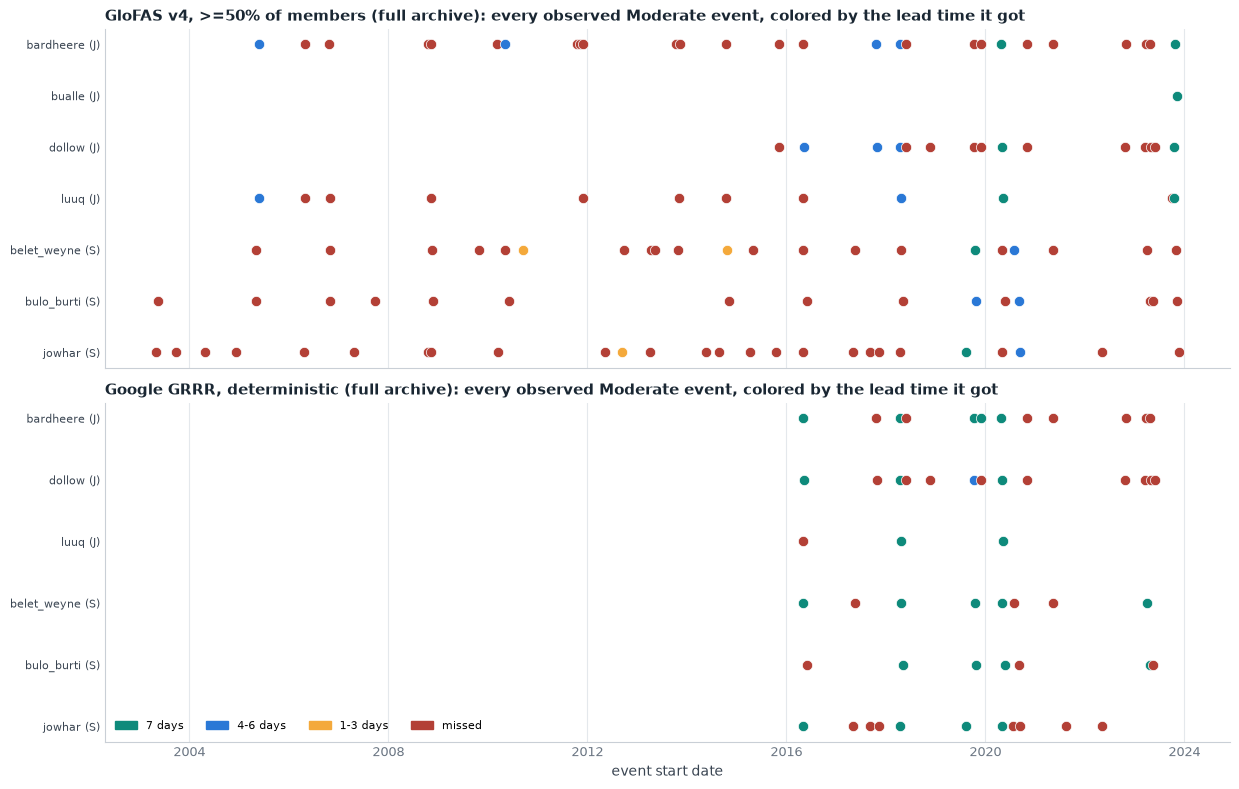

In [9]:
import matplotlib.patches as mpatches

BUCKETS = [
    (7, 7, "#0E8A7B", "7 days"),
    (4, 6, "#2A78D6", "4-6 days"),
    (1, 3, "#F4A93B", "1-3 days"),
    (0, 0, "#B34036", "missed"),
]

def bucket_color(w):
    for lo, hi, color, _ in BUCKETS:
        if lo <= w <= hi:
            return color
    return "#B34036"

fig, axes = plt.subplots(2, 1, figsize=(12.5, 8), sharex=True)
for ax, src_name in zip(axes, ["glofas", "google"]):
    sub = events_tab[(events_tab.source == src_name) & (events_tab.wtype == "full") & (events_tab.bench == "moderate")]
    st_order = sorted(sub.station.unique(), key=lambda s: (STATIONS[s].river, s))
    ypos = {s: i for i, s in enumerate(st_order)}
    for _, r in sub.iterrows():
        ax.scatter(r.start, ypos[r.station], color=bucket_color(r.max_warning),
                   s=55, zorder=5, edgecolors="white", linewidths=0.5)
    ax.set_yticks(range(len(st_order)))
    ax.set_yticklabels(
        [f"{s} ({STATIONS[s].river[0].upper()})" for s in st_order], fontsize=8
    )
    ax.invert_yaxis()
    ax.set_title(
        f"{SRC_LABEL[src_name]} (full archive): every observed Moderate event, "
        "colored by the lead time it got",
        fontsize=11,
    )
    style_ax(ax)
axes[1].legend(
    handles=[mpatches.Patch(color=c, label=lab) for _, _, c, lab in BUCKETS],
    ncol=4,
    fontsize=8,
    loc="lower left",
)
axes[1].set_xlabel("event start date")
plt.tight_layout()


In [10]:
PANELS = [
    ("glofas", "common", "GloFAS v4 >=50% | common 2016-23"),
    ("glofas", "full", "GloFAS v4 >=50% | full 2003-23"),
    ("google", "common", "Google GRRR | 2016-23"),
]
fig, axes = plt.subplots(3, 2, figsize=(13, 13))
for r_i, (src_name, wtype, plabel) in enumerate(PANELS):
    sub = events_tab[(events_tab.source == src_name) & (events_tab.wtype == wtype) & (events_tab.bench == "moderate")]
    st_order = sorted(sub.station.unique(), key=lambda s: (STATIONS[s].river, s))
    n_ev = {s: int((sub.station == s).sum()) for s in st_order}
    row_labels = [
        f"{s} ({STATIONS[s].river[0].upper()}) | {n_ev[s]} events" for s in st_order
    ]
    pod = np.array(
        [[100 * (sub[sub.station == s].max_warning >= L).mean() for L in LEADS_EV]
         for s in st_order]
    )
    fsub = fa_tab[(fa_tab.source == src_name) & (fa_tab.wtype == wtype) & (fa_tab.bench == "moderate")]
    far = np.full((len(st_order), len(LEADS_EV)), np.nan)
    far_txt = [["-"] * len(LEADS_EV) for _ in st_order]
    for si, s in enumerate(st_order):
        for li, L in enumerate(LEADS_EV):
            g = fsub[(fsub.station == s) & (fsub.lead == L)]
            if len(g) and g.n_alarms.sum() > 0:
                nf, na = int(g.n_false.sum()), int(g.n_alarms.sum())
                far[si, li] = 100 * nf / na
                far_txt[si][li] = f"{nf}/{na}"
    for col, (mat, name) in enumerate([(pod, "POD"), (far, "FAR")]):
        ax = axes[r_i][col]
        shade = mat / 100 if name == "POD" else 1 - mat / 100  # dark = better
        ax.imshow(shade, vmin=0, vmax=1, cmap="Blues", aspect="auto")
        ax.set_xticks(range(len(LEADS_EV)))
        ax.set_xticklabels(LEADS_EV, fontsize=8)
        ax.set_yticks(range(len(st_order)))
        ax.set_yticklabels(row_labels if col == 0 else [""] * len(st_order),
                           fontsize=8)
        ax.set_xticks([x - 0.5 for x in range(len(LEADS_EV) + 1)], minor=True)
        ax.set_yticks([y - 0.5 for y in range(len(st_order) + 1)], minor=True)
        ax.grid(which="minor", color="white", linewidth=1.0)
        ax.tick_params(which="both", length=0)
        for sp in ax.spines.values():
            sp.set_visible(False)
        for (i, j), v in np.ndenumerate(mat):
            if name == "FAR":
                txt = far_txt[i][j]
            else:
                txt = "-" if np.isnan(v) else f"{v:.0f}"
            sh = 0 if np.isnan(v) else shade[i, j]
            ax.text(j, i, txt, ha="center", va="center", fontsize=7.5,
                    color="white" if sh > 0.55 else INK)
        ax.set_xlabel("minimum lead time (>= L days)")
        ax.set_title(
            f"{plabel} | POD % (dark = better)" if name == "POD"
            else "FAR as false/total alarms at lead >= L (dark = better)",
            fontsize=10,
        )
plt.tight_layout()


## 3. Technical appendix: GloFAS day-level skill by lead

Stricter day-level scoring (every flood day counted separately): kept for reference; the event-level section above is the operational read. Like section 2, all windows are cumulative: the value at L uses the strongest forecast signal at any lead of L days or less.

Threshold = the source's RP3 / RP5. Trigger = a fraction of the 11 members
exceeding it; the best of 1/11, 25%, 50% is reported per cell (this is a
best-case, post-hoc choice: read it as an upper bound). Scored on
`valid_time`, which already carries GloFAS's end-of-period correction.

Note on reading FAR anywhere in this notebook: it is a ratio, not a
count. As the lead requirement tightens, both false alarms and total
alarms shrink, so the ratio can legitimately dip and rise; the
monotone cost measure is false alarms per year, shown in the
event-level figures.

In [11]:
# post-2000 RP3 observed level per station (same estimator as notebook 01)
POST2000_RP3 = {}
for st in gauged:
    s = lv.loc[st]
    s2 = s[s.index.year >= 2000]
    am = s2.groupby(s2.index.year).max().dropna()
    POST2000_RP3[st] = weibull_level(am.values, 3)


# Both benchmarks (decision 2026-08-06): official Moderate + post-2000 RP3.
def obs_benchmarks(st):
    return {
        "moderate": th.loc[st, "moderate_flood_risk"],
        "rp3_post2000": POST2000_RP3.get(st, np.nan),
    }

rows = []
for st in gauged:
    obs = lv.loc[st]
    series = ra_glofas[ra_glofas.station == st].set_index("date")["discharge"]
    sub = rf_glofas[rf_glofas.station == st]
    if not len(sub):
        continue
    for bench, thr in obs_benchmarks(st).items():
        if np.isnan(thr):
            continue
        for T in (3, 5):
            q = gumbel_rp(series, T)
            for lead in range(1, 8):
                # cumulative: strongest signal at any lead of <= L days
                d = sub[sub.leadtime_days <= lead]
                frac = (
                    d.groupby(["valid_time", "leadtime_days"])["discharge"]
                    .apply(lambda x: (x >= q).mean())
                    .groupby("valid_time")
                    .max()
                )
                j = pd.concat([frac.rename("p"), obs.rename("lev")], axis=1, join="inner").dropna()
                fl = j["lev"] >= thr
                if fl.sum() < 5:
                    continue
                best = None
                for pc in (1 / 11, 0.25, 0.5):
                    fire = j["p"] >= pc - 1e-9
                    tp = (fire & fl).sum(); fp = (fire & ~fl).sum(); fn = (~fire & fl).sum()
                    pod = tp / (tp + fn) if tp + fn else 0
                    far = fp / (tp + fp) if tp + fp else np.nan
                    score = pod * (1 - (far if far == far else 1))
                    if best is None or score > best[0]:
                        best = (score, pc, pod, far)
                rows.append({"station": st, "bench": bench, "rp": f"rp{T}", "lead": lead,
                             "flood_days": int(fl.sum()), "member_cut": round(best[1], 2),
                             "POD": best[2], "FAR": best[3], "AUC": auc(j["p"].values, fl.values)})
skill = pd.DataFrame(rows)
skill[skill.rp == "rp3"].pivot(index=["bench", "station"], columns="lead", values=["POD", "FAR"]).round(2)


POD                                       FAR  \
lead                         1     2     3     4     5     6     7     1   
bench        station                                                       
moderate     bardheere    0.15  0.15  0.17  0.18  0.19  0.19  0.19  0.16   
             belet_weyne  0.03  0.03  0.03  0.03  0.03  0.03  0.03  0.65   
             bualle       1.00  1.00  1.00  1.00  1.00  1.00  1.00  0.81   
             bulo_burti   0.03  0.03  0.03  0.03  0.03  0.03  0.03  0.80   
             dollow       0.33  0.32  0.36  0.38  0.38  0.39  0.40  0.08   
             jowhar       0.04  0.04  0.04  0.04  0.04  0.05  0.05  0.32   
             luuq         0.34  0.36  0.41  0.44  0.44  0.44  0.44  0.62   
rp3_post2000 bardheere    0.60  0.58  0.68  0.71  0.71  0.71  0.71  0.81   
             belet_weyne  0.00  0.00  0.00  0.00  0.00  0.00  0.00  1.00   
             bualle       0.34  0.36  0.41  0.44  0.44  0.45  0.46  0.58   
             bulo_burti   0.06  0.05  0.05  0.04  0.04  0.04  0.05  0.80   
             dollow       0.69  0.75  0.81  0.83  0.83  0.83  0.83  0.64   
             jowhar       0.06  0.07  0.07  0.09  0.11  0.12  0.14  0.90   
             luuq         0.35  0.38  0.48  0.52  0.52  0.50  0.50  0.79   

                                                              
lead                         2     3     4     5     6     7  
bench        station                                          
moderate     bardheere    0.15  0.13  0.13  0.13  0.14  0.14  
             belet_weyne  0.67  0.67  0.67  0.68  0.65  0.65  
             bualle       0.78  0.71  0.67  0.66  0.65  0.64  
             bulo_burti   0.82  0.82  0.82  0.82  0.82  0.83  
             dollow       0.07  0.07  0.06  0.08  0.08  0.08  
             jowhar       0.31  0.31  0.31  0.35  0.38  0.39  
             luuq         0.59  0.53  0.50  0.51  0.52  0.53  
rp3_post2000 bardheere    0.80  0.73  0.70  0.70  0.70  0.70  
             belet_weyne  1.00  1.00  1.00  1.00  1.00  1.00  
             bualle       0.58  0.50  0.47  0.46  0.45  0.45  
             bulo_burti   0.82  0.82  0.82  0.82  0.82  0.83  
             dollow       0.59  0.53  0.50  0.51  0.52  0.52  
             jowhar       0.88  0.88  0.88  0.87  0.87  0.86  
             luuq         0.75  0.66  0.64  0.65  0.64  0.64

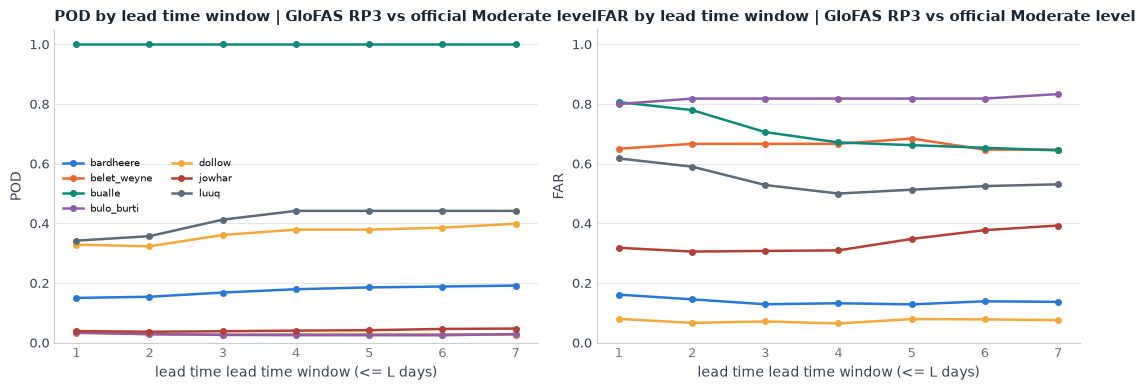

In [12]:
plot = skill[(skill.rp == "rp3") & (skill.bench == "moderate")]
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharex=True)
for ax, metric in zip(axes, ["POD", "FAR"]):
    piv = plot.pivot(index="lead", columns="station", values=metric)
    for stn in piv.columns:
        ax.plot(piv.index, piv[stn], marker="o", ms=4, lw=1.8, label=stn)
    ax.set_xlabel("lead time lead time window (<= L days)")
    ax.set_ylabel(metric)
    ax.set_ylim(0, 1.05)
    ax.set_title(
        f"{metric} by lead time window | GloFAS RP3 vs official Moderate level", fontsize=10.5
    )
    style_ax(ax, grid="y")
axes[0].legend(fontsize=7, ncol=2)
plt.tight_layout()


### RP5

In [13]:
skill[skill.rp == "rp5"].pivot(index=["bench", "station"], columns="lead", values=["POD", "FAR"]).round(2)


POD                                       FAR  \
lead                         1     2     3     4     5     6     7     1   
bench        station                                                       
moderate     bardheere    0.02  0.02  0.03  0.03  0.03  0.04  0.05  0.00   
             belet_weyne  0.00  0.00  0.00  0.00  0.00  0.01  0.01  1.00   
             bualle       0.67  0.69  0.75  0.75  0.76  0.77  0.74  0.00   
             bulo_burti   0.00  0.00  0.00  0.00  0.00  0.00  0.00  1.00   
             dollow       0.10  0.11  0.14  0.16  0.17  0.18  0.18  0.00   
             jowhar       0.01  0.01  0.01  0.01  0.01  0.01  0.01  0.33   
             luuq         0.08  0.10  0.15  0.19  0.21  0.19  0.19  0.00   
rp3_post2000 bardheere    0.30  0.32  0.36  0.36  0.36  0.32  0.32  0.00   
             belet_weyne  0.00  0.00  0.00  0.00  0.00  0.00  0.00  1.00   
             bualle       0.11  0.13  0.18  0.20  0.21  0.22  0.22  0.00   
             bulo_burti   0.00  0.00  0.00  0.00  0.00  0.00  0.01  1.00   
             dollow       0.46  0.50  0.52  0.51  0.51  0.49  0.49  0.14   
             jowhar       0.00  0.00  0.00  0.00  0.00  0.02  0.02  1.00   
             luuq         0.15  0.18  0.25  0.27  0.29  0.29  0.29  0.00   

                                                              
lead                         2     3     4     5     6     7  
bench        station                                          
moderate     bardheere    0.00  0.00  0.09  0.08  0.13  0.12  
             belet_weyne  1.00  1.00  0.94  0.88  0.84  0.80  
             bualle       0.00  0.00  0.00  0.00  0.00  0.00  
             bulo_burti   1.00  1.00  1.00  1.00  1.00  0.95  
             dollow       0.00  0.00  0.04  0.04  0.03  0.03  
             jowhar       0.20  0.20  0.27  0.27  0.25  0.25  
             luuq         0.12  0.08  0.06  0.14  0.06  0.06  
rp3_post2000 bardheere    0.00  0.00  0.09  0.17  0.10  0.10  
             belet_weyne  1.00  1.00  1.00  1.00  1.00  1.00  
             bualle       0.00  0.00  0.00  0.00  0.00  0.00  
             bulo_burti   1.00  1.00  1.00  1.00  1.00  0.95  
             dollow       0.08  0.16  0.22  0.25  0.23  0.23  
             jowhar       1.00  1.00  1.00  1.00  0.92  0.92  
             luuq         0.12  0.08  0.12  0.12  0.12  0.12

### Threshold-free: ROC AUC by lead

Removes the threshold choice entirely: can the forecast rank flood days above
non-flood days at all? 0.5 is a coin flip.

In [14]:
auc_tab = (skill[(skill.rp == "rp3") & (skill.bench == "moderate")]
           .pivot(index="station", columns="lead", values="AUC"))
skill[skill.rp == "rp3"].pivot(index=["bench", "station"], columns="lead", values="AUC").round(3)


lead                          1      2      3      4      5      6      7
bench        station                                                     
moderate     bardheere    0.574  0.576  0.583  0.589  0.592  0.593  0.595
             belet_weyne  0.513  0.511  0.510  0.511  0.511  0.510  0.511
             bualle       0.992  0.992  0.992  0.992  0.993  0.993  0.993
             bulo_burti   0.513  0.511  0.510  0.509  0.509  0.509  0.511
             dollow       0.663  0.660  0.679  0.688  0.688  0.691  0.698
             jowhar       0.517  0.517  0.517  0.519  0.519  0.520  0.521
             luuq         0.666  0.674  0.702  0.716  0.716  0.716  0.716
rp3_post2000 bardheere    0.794  0.784  0.834  0.851  0.851  0.851  0.851
             belet_weyne  0.495  0.495  0.496  0.496  0.496  0.495  0.495
             bualle       0.665  0.675  0.702  0.714  0.717  0.720  0.723
             bulo_burti   0.525  0.521  0.519  0.519  0.518  0.518  0.521
             dollow       0.836  0.866  0.894  0.905  0.905  0.905  0.905
             jowhar       0.525  0.531  0.531  0.539  0.548  0.556  0.565
             luuq         0.668  0.686  0.734  0.754  0.754  0.754  0.754

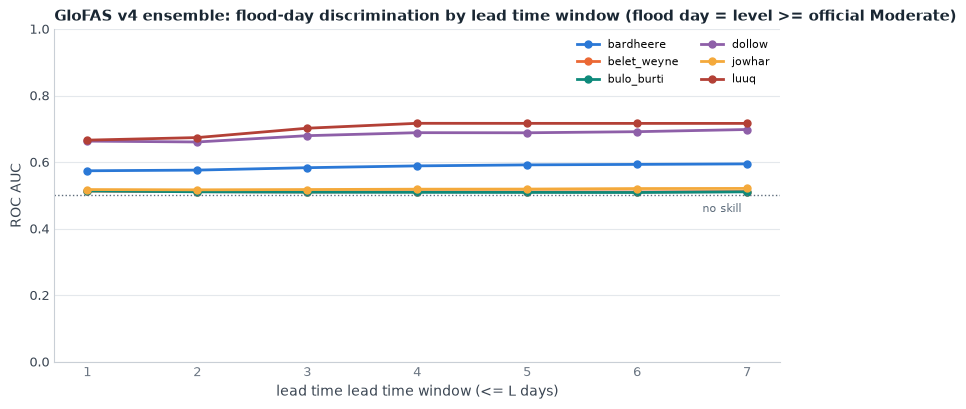

In [15]:
fig, ax = plt.subplots(figsize=(8, 4.2))
for st in auc_tab.index:
    if st == "bualle":  # 6 flood days: artifact, excluded from the plot
        continue
    ax.plot(auc_tab.columns, auc_tab.loc[st], marker="o", lw=2, ms=5, label=st)
ax.axhline(0.5, color=C_REF, ls=":", lw=1)
ax.annotate(
    "no skill",
    (7, 0.5),
    textcoords="offset points",
    xytext=(-4, -12),
    ha="right",
    fontsize=8,
    color=C_REF,
)
ax.set_xlabel("lead time lead time window (<= L days)")
ax.set_ylabel("ROC AUC")
ax.set_title(
    "GloFAS v4 ensemble: flood-day discrimination by lead time window "
    "(flood day = level >= official Moderate)",
    fontsize=11,
)
ax.set_ylim(0, 1)
ax.legend(fontsize=8, ncol=2)
style_ax(ax, grid="y")
plt.tight_layout()


### 3b. Technical: cross-source AUC by lead

Each on its own archive window: not the same events. GEOGloWS is scored with
forecast-native (frequency-matched) thresholds because its retrospective RPs
cannot fire; GRRR is deterministic, so "member fraction" is 0 or 1.

In [16]:
rows = []
# GEOGloWS archive (2024-07 onwards)
for st in gauged:
    obs = lv.loc[st]
    sub = rf_geo[rf_geo.station == st]
    if not len(sub):
        continue
    for bench, thr in obs_benchmarks(st).items():
        if np.isnan(thr):
            continue
        for lead in range(1, 8):
            d = sub[(sub.leadtime_days >= 1) & (sub.leadtime_days <= lead)]
            med = (
                d.groupby(["valid_time", "leadtime_days"])["discharge"]
                .median()
                .groupby("valid_time")
                .max()
            )
            j = pd.concat([med.rename("q"), obs.rename("lev")], axis=1, join="inner").dropna()
            fl = j["lev"] >= thr
            if fl.sum() < 5:
                continue
            rows.append({"station": st, "source": "geoglows", "bench": bench, "lead": lead,
                         "AUC": auc(j["q"].values, fl.values), "flood_days": int(fl.sum())})
# Google GRRR (2016-2023)
for st in gauged:
    obs = lv.loc[st]
    sub = rf_grrr[rf_grrr.station == st]
    if not len(sub):
        continue
    for bench, thr in obs_benchmarks(st).items():
        if np.isnan(thr):
            continue
        for lead in range(1, 8):
            d = (
                sub[(sub.leadtime_days >= 1) & (sub.leadtime_days <= lead)]
                .groupby("valid_time")["discharge"]
                .max()
            )
            j = pd.concat([d.rename("q"), obs.rename("lev")], axis=1, join="inner").dropna()
            fl = j["lev"] >= thr
            if fl.sum() < 5:
                continue
            rows.append({"station": st, "source": "google", "bench": bench, "lead": lead,
                         "AUC": auc(j["q"].values, fl.values), "flood_days": int(fl.sum())})
for _, r in skill[skill.rp == "rp3"].iterrows():
    rows.append({"station": r.station, "source": "glofas", "bench": r.bench, "lead": r.lead,
                 "AUC": r.AUC, "flood_days": r.flood_days})
cross = pd.DataFrame(rows)
cross.pivot_table(index=["bench", "station"], columns=["source", "lead"], values="AUC").round(2)


source                   geoglows                                     glofas  \
lead                            1     2     3     4     5     6     7      1   
bench        station                                                           
moderate     bardheere        NaN   NaN   NaN   NaN   NaN   NaN   NaN   0.57   
             belet_weyne     0.79  0.79  0.79  0.78  0.78  0.78  0.78   0.51   
             bualle           NaN   NaN   NaN   NaN   NaN   NaN   NaN   0.99   
             bulo_burti      0.82  0.82  0.82  0.81  0.81  0.81  0.81   0.51   
             dollow          0.93  0.93  0.93  0.93  0.93  0.93  0.93   0.66   
             jowhar          0.96  0.96  0.96  0.96  0.96  0.96  0.96   0.52   
             luuq             NaN   NaN   NaN   NaN   NaN   NaN   NaN   0.67   
rp3_post2000 bardheere        NaN   NaN   NaN   NaN   NaN   NaN   NaN   0.79   
             belet_weyne      NaN   NaN   NaN   NaN   NaN   NaN   NaN   0.50   
             bualle           NaN   NaN   NaN   NaN   NaN   NaN   NaN   0.67   
             bulo_burti      0.86  0.85  0.85  0.85  0.85  0.85  0.85   0.52   
             dollow           NaN   NaN   NaN   NaN   NaN   NaN   NaN   0.84   
             jowhar           NaN   NaN   NaN   NaN   NaN   NaN   NaN   0.53   
             luuq             NaN   NaN   NaN   NaN   NaN   NaN   NaN   0.67   

source                                ...                   google        \
lead                         2     3  ...     5     6     7      1     2   
bench        station                  ...                                  
moderate     bardheere    0.58  0.58  ...  0.59  0.59  0.59   0.92  0.92   
             belet_weyne  0.51  0.51  ...  0.51  0.51  0.51   0.97  0.97   
             bualle       0.99  0.99  ...  0.99  0.99  0.99    NaN   NaN   
             bulo_burti   0.51  0.51  ...  0.51  0.51  0.51   0.92  0.92   
             dollow       0.66  0.68  ...  0.69  0.69  0.70   0.94  0.95   
             jowhar       0.52  0.52  ...  0.52  0.52  0.52   0.80  0.80   
             luuq         0.67  0.70  ...  0.72  0.72  0.72   0.98  0.98   
rp3_post2000 bardheere    0.78  0.83  ...  0.85  0.85  0.85    NaN   NaN   
             belet_weyne  0.50  0.50  ...  0.50  0.50  0.50   0.95  0.95   
             bualle       0.68  0.70  ...  0.72  0.72  0.72   0.97  0.97   
             bulo_burti   0.52  0.52  ...  0.52  0.52  0.52   0.92  0.92   
             dollow       0.87  0.89  ...  0.90  0.90  0.90   1.00  1.00   
             jowhar       0.53  0.53  ...  0.55  0.56  0.56   0.68  0.68   
             luuq         0.69  0.73  ...  0.75  0.75  0.75   0.97  0.97   

source                                                  
lead                         3     4     5     6     7  
bench        station                                    
moderate     bardheere    0.92  0.92  0.92  0.92  0.92  
             belet_weyne  0.97  0.97  0.97  0.97  0.97  
             bualle        NaN   NaN   NaN   NaN   NaN  
             bulo_burti   0.92  0.92  0.92  0.92  0.92  
             dollow       0.95  0.95  0.95  0.95  0.95  
             jowhar       0.80  0.80  0.80  0.80  0.80  
             luuq         0.98  0.98  0.98  0.98  0.98  
rp3_post2000 bardheere     NaN   NaN   NaN   NaN   NaN  
             belet_weyne  0.95  0.95  0.95  0.95  0.95  
             bualle       0.97  0.97  0.98  0.98  0.98  
             bulo_burti   0.92  0.92  0.92  0.92  0.92  
             dollow       1.00  1.00  1.00  1.00  1.00  
             jowhar       0.68  0.68  0.68  0.68  0.68  
             luuq         0.97  0.97  0.97  0.97  0.97  

[14 rows x 21 columns]

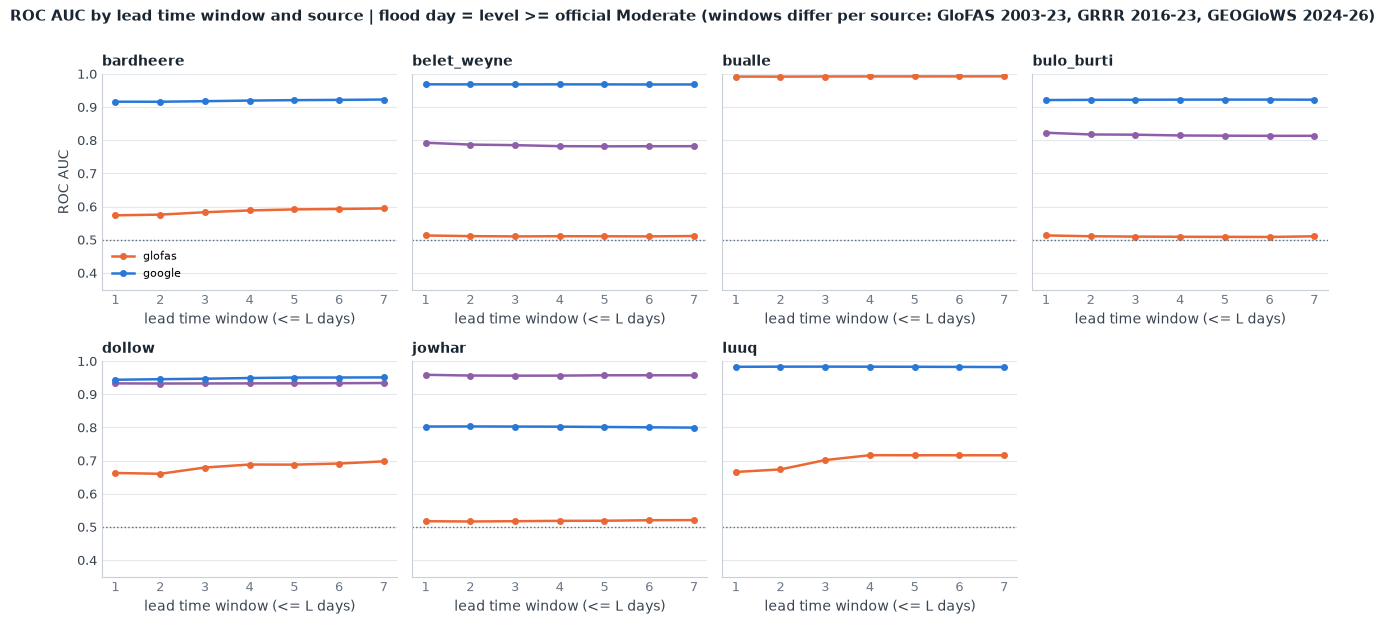

In [17]:
plot = cross[cross.bench == "moderate"]
stations_p = sorted(plot.station.unique())
SRC_C = {"geoglows": C_GEOGLOWS, "google": C_GOOGLE, "glofas": C_GLOFAS4}
ncols = 4
nrows = -(-len(stations_p) // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(13, 3.1 * nrows), sharey=True)
axf = np.atleast_1d(axes).ravel()
for k, stn in enumerate(stations_p):
    ax = axf[k]
    sub = plot[plot.station == stn]
    for srcname, g in sub.groupby("source"):
        g = g.sort_values("lead")
        ax.plot(
            g.lead, g.AUC, marker="o", ms=4, lw=1.8,
            color=SRC_C[srcname], label=srcname,
        )
    ax.axhline(0.5, color=C_REF, ls=":", lw=1)
    ax.set_ylim(0.35, 1.0)
    ax.set_title(stn, fontsize=10)
    ax.set_xlabel("lead time window (<= L days)")
    style_ax(ax, grid="y")
for ax in axf[len(stations_p):]:
    ax.set_visible(False)
axf[0].set_ylabel("ROC AUC")
axf[0].legend(fontsize=8)
fig.suptitle(
    "ROC AUC by lead time window and source | flood day = level >= official Moderate "
    "(windows differ per source: GloFAS 2003-23, GRRR 2016-23, GEOGloWS 2024-26)",
    fontweight="bold", color=INK, fontsize=11, y=1.0,
)
plt.tight_layout()


### 3c. Technical: GRRR as a hard day-level RP3 trigger

The AUC table shows GRRR ranks flood days extremely well (0.92-0.97 on the
Shabelle). Does that survive as a hard RP3 trigger? Deterministic forecast >=
GRRR's own RP3, scored day-level against the moderate level.

In [18]:
grrr_rp = load("return_periods_google_grrr").pivot(index="station", columns="return_period", values="discharge")
rows = []
for st in gauged:
    if st not in grrr_rp.index:
        continue
    q2, q5 = grrr_rp.loc[st, 2], grrr_rp.loc[st, 5]
    q3 = q2 + (q5 - q2) * (yT(3) - yT(2)) / (yT(5) - yT(2))
    obs = lv.loc[st]
    sub = rf_grrr[rf_grrr.station == st]
    for bench, thr in obs_benchmarks(st).items():
        if np.isnan(thr):
            continue
        for lead in range(1, 8):
            d = (
                sub[(sub.leadtime_days >= 1) & (sub.leadtime_days <= lead)]
                .groupby("valid_time")["discharge"]
                .max()
            )
            j = pd.concat([d.rename("q"), obs.rename("lev")], axis=1, join="inner").dropna()
            fl = j["lev"] >= thr
            if fl.sum() < 5:
                continue
            fire = j["q"] >= q3
            tp = (fire & fl).sum(); fp = (fire & ~fl).sum(); fn = (~fire & fl).sum()
            rows.append({"station": st, "bench": bench, "lead": lead,
                         "POD": tp / (tp + fn) if tp + fn else np.nan,
                         "FAR": fp / (tp + fp) if tp + fp else np.nan})
grrr_trig = pd.DataFrame(rows)
grrr_trig.pivot(index=["bench", "station"], columns="lead", values=["POD", "FAR"]).round(2)


POD                                       FAR  \
lead                         1     2     3     4     5     6     7     1   
bench        station                                                       
moderate     bardheere    0.30  0.30  0.30  0.31  0.31  0.31  0.31  0.12   
             belet_weyne  0.14  0.15  0.17  0.17  0.18  0.19  0.22  0.04   
             bulo_burti   0.02  0.02  0.03  0.03  0.06  0.09  0.11  0.94   
             dollow       0.19  0.20  0.23  0.24  0.26  0.29  0.32  0.24   
             jowhar       0.09  0.09  0.10  0.11  0.12  0.12  0.13  0.24   
             luuq         0.81  0.81  0.81  0.81  0.81  0.81  0.81  0.78   
rp3_post2000 belet_weyne  0.12  0.12  0.12  0.12  0.14  0.16  0.17  0.83   
             bualle       0.60  0.60  0.60  0.60  0.60  0.60  0.60  0.52   
             bulo_burti   0.00  0.00  0.01  0.01  0.05  0.09  0.11  1.00   
             dollow       0.83  0.83  1.00  1.00  1.00  1.00  1.00  0.83   
             jowhar       0.27  0.27  0.27  0.27  0.27  0.27  0.27  0.93   
             luuq         0.62  0.62  0.62  0.62  0.62  0.62  0.62  0.92   

                                                              
lead                         2     3     4     5     6     7  
bench        station                                          
moderate     bardheere    0.12  0.12  0.13  0.13  0.15  0.18  
             belet_weyne  0.04  0.05  0.05  0.09  0.12  0.17  
             bulo_burti   0.94  0.93  0.94  0.88  0.83  0.81  
             dollow       0.28  0.25  0.24  0.23  0.21  0.20  
             jowhar       0.29  0.32  0.35  0.34  0.35  0.37  
             luuq         0.78  0.78  0.79  0.79  0.81  0.81  
rp3_post2000 belet_weyne  0.85  0.86  0.86  0.86  0.86  0.87  
             bualle       0.52  0.54  0.55  0.55  0.55  0.58  
             bulo_burti   1.00  0.98  0.98  0.93  0.90  0.88  
             dollow       0.84  0.83  0.84  0.85  0.86  0.87  
             jowhar       0.94  0.95  0.95  0.96  0.96  0.96  
             luuq         0.92  0.92  0.92  0.92  0.93  0.93

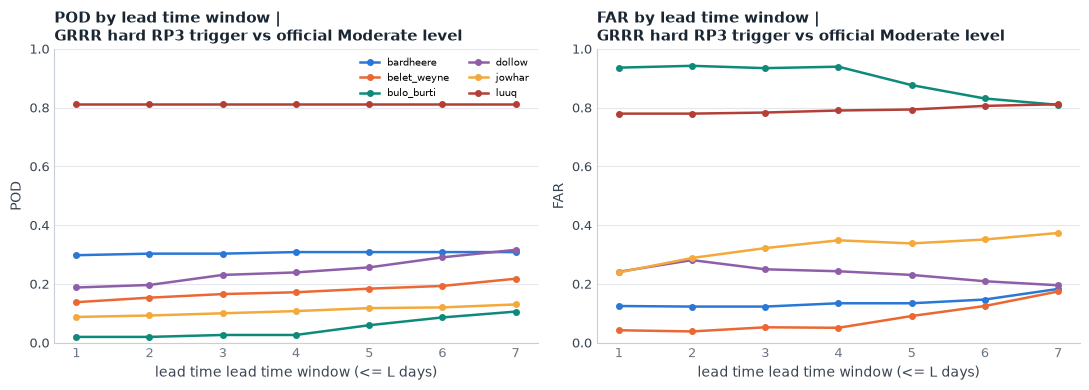

In [ ]:
plot = grrr_trig[grrr_trig.bench == "moderate"]
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharex=True)
for ax, metric in zip(axes, ["POD", "FAR"]):
    piv = plot.pivot(index="lead", columns="station", values=metric)
    for stn in piv.columns:
        ax.plot(piv.index, piv[stn], marker="o", ms=4, lw=1.8, label=stn)
    ax.set_xlabel("lead time lead time window (<= L days)")
    ax.set_ylabel(metric)
    ax.set_ylim(0, 1)
    ax.set_title(
        f"{metric} by lead time window | \nGRRR hard RP3 trigger vs official Moderate level",
        fontsize=10.5,
    )
    style_ax(ax, grid="y")
axes[0].legend(fontsize=7, ncol=2)
plt.tight_layout()


## Findings (dual benchmarks | GloFAS = v4 reforecast by necessity)

**Skill is flat from lead 1 to lead 7, for every source and both benchmarks.**
These rivers are predictable from water already in the channel upstream, not
from rainfall forecasts, so a 7-day lead time costs almost nothing relative to
a 1-day one. This is what makes the 7-12 day readiness leg viable.

**Google GRRR has the ranking skill at lead time** (2016-2023). AUC vs the
post-2000 RP3 benchmark: Dollow 1.00 | Luuq 0.97 | Bualle 0.97 |
Belet Weyne 0.95 | Bulo Burti 0.92 | Jowhar 0.68, essentially unchanged out
to lead 7. But section 3b shows the catch: as a hard day-level RP3 trigger
its FAR is 0.8+ everywhere except Bualle (0.5): great ranking does not mean
a clean binary trigger. The N-of-M episode-level rules in notebook 09 are
how that skill gets used operationally (Gu windows: POD 1.0 at FAR 0.0-0.25).

**GloFAS v4 forecasts are usable on the Juba only.** Vs the post-2000 RP3
benchmark: Dollow AUC 0.80-0.89, Bardheere 0.72-0.80 (day-level POD 0.5-0.8
at FAR 0.55-0.75); the Shabelle stations sit at coin-flip (Belet Weyne 0.50,
Bulo Burti 0.50-0.53). v4's Shabelle weakness carries straight into the Deyr
forecast legs in notebooks 09-10; a published v5 reforecast is the single
biggest upgrade this framework is waiting on.

**Benchmark note.** Every SWALIM comparison in this notebook: the
event-level section and the technical appendix: scores against the official
Moderate Flood Risk level. Beware single-event rows (Bualle's Moderate sits
at 9.0 m and was reached only in 2023, so its POD 100% rests on one event:
counts are in the row labels).

**GEOGloWS remains a watch item, not a trigger.** Its 2024-2026 archive is
too short to score at the post-2000 RP3 level at most stations (only Bulo
Burti, AUC 0.85-0.86), and its forecasts must never be thresholded with
retrospective-derived RPs (section 1: forecast climatology runs 0.6-0.7x its
retrospective). Revisit as the archive grows.

Scoring is day-level here (each flood day counts separately), which is
stricter than the episode-level matching used in notebooks 02 and 09: read
FAR accordingly.
